# Результаты оценки планнера: история, frozen и adaptive

Что прогонялось: бюджет 1,2 млн ₽, 21 день, цель — конверсии, 8 каналов, случайные события мира выключены.

- **4 мира** (`world_seed` 1–4) — у каждого свои скрытые CTR, CR, CPM и ёмкость внутри публичных диапазонов.
- **История**: `h0` — план по каталогу (середины публичных диапазонов), `h3` — план по фактам трёх прошлых кампаний на том же мире.
- **Режим**: `frozen` — утверждённые caps не меняются; `adaptive` — каждый час факты уходят планнеру, он пересчитывает остаток.
- **Сценарии**: без шока, CTR −40 %, CPM +60 %, спрос −50 %, пауза канала на 72 ч. Шок бьёт по каналу с наибольшим бюджетом с середины кампании.

Метрика кейса — отклонение накопленного факта от утверждённого плана в конце кампании, порог 20 %.
Все режимы одной ячейки идут на одинаковых seed и шоке, поэтому разница между ними — только история или только адаптация.

In [1]:
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

RESULTS = Path('.').resolve()
if not (RESULTS / 'runs.json').exists():
    RESULTS = Path('media_planner/tools/evaluation/results')
runs = pd.DataFrame(json.load(open(RESULTS / 'runs.json')))
runs['history'] = runs['history'].map({0: 'h0 каталог', 3: 'h3 история'})
FIG = RESULTS / 'figures'; FIG.mkdir(exist_ok=True)
pct = lambda x: f'{x:+.0%}'
print(len(runs), 'прогонов')

80 прогонов


## 1. Насколько план попадает в факт: каталог против истории (frozen, без шока)

In [2]:
none = runs[(runs.scenario == 'none')]
table = none.pivot_table(index='world_seed', columns=['history', 'mode'], values='final_dev_kpi')
table.map(pct)

history    h0 каталог        h3 история       
mode         adaptive frozen   adaptive frozen
world_seed                                    
1               +121%  +102%       +17%   +18%
2                +68%   +68%       +10%   +22%
3                -11%   -26%        -1%    +2%
4                 +1%   -24%        +8%    +8%

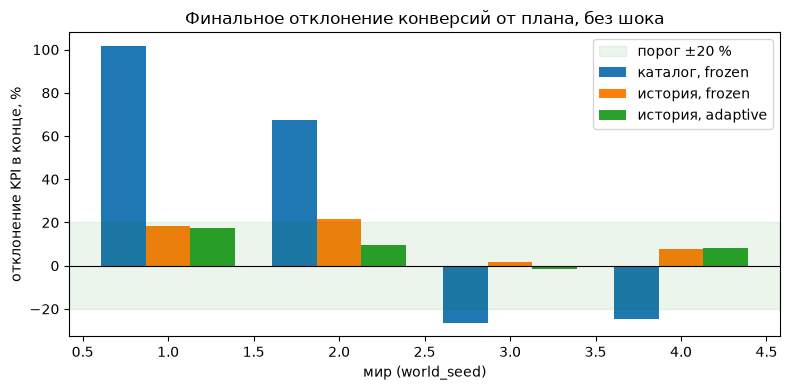

In [3]:
fig, ax = plt.subplots(figsize=(8, 4))
order = [('h0 каталог', 'frozen'), ('h3 история', 'frozen'), ('h3 история', 'adaptive')]
labels = ['каталог, frozen', 'история, frozen', 'история, adaptive']
width = 0.26
for i, ((h, m), label) in enumerate(zip(order, labels)):
    sub = none[(none.history == h) & (none['mode'] == m)].sort_values('world_seed')
    ax.bar(sub.world_seed + (i - 1) * width, sub.final_dev_kpi * 100, width, label=label)
ax.axhspan(-20, 20, color='green', alpha=0.08, label='порог ±20 %')
ax.axhline(0, color='black', lw=0.8)
ax.set_xlabel('мир (world_seed)'); ax.set_ylabel('отклонение KPI в конце, %')
ax.set_title('Финальное отклонение конверсий от плана, без шока'); ax.legend()
fig.tight_layout(); fig.savefig(FIG / 'final_dev_by_world.png', dpi=120); plt.show()

Читать так: по каталогу план промахивается на −25…+100 % в зависимости от мира — это ширина публичных диапазонов, а не ошибка исполнения. С историей трёх кампаний frozen попадает в порог в 3 мирах из 4, adaptive — в 4 из 4.

## 2. Траектории: план и факт по часам

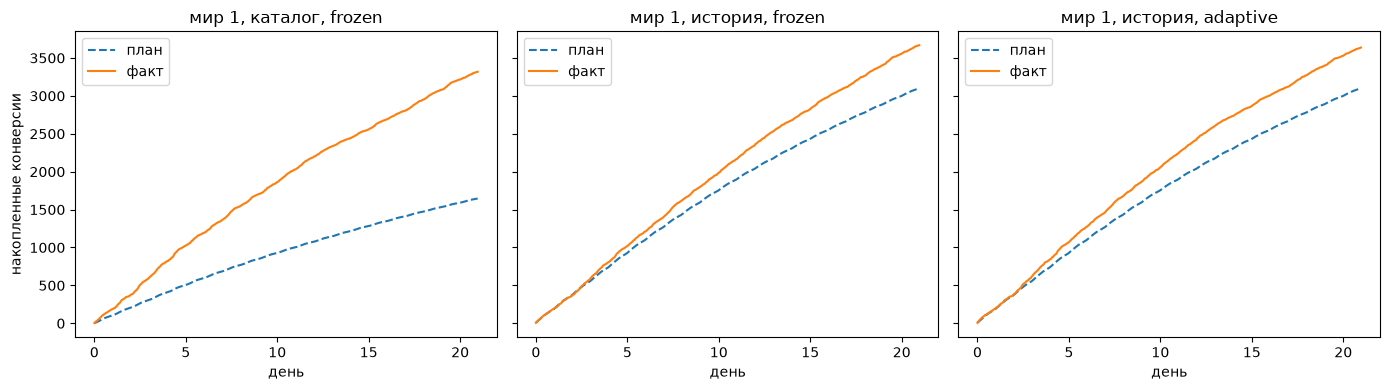

In [4]:
def traj(run_id):
    return pd.read_csv(RESULTS / 'trajectories' / f'{run_id}.csv')

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
for ax, (run_id, title) in zip(axes, [
    ('w1-c1-h0-none-frozen', 'мир 1, каталог, frozen'),
    ('w1-c1-h3-none-frozen', 'мир 1, история, frozen'),
    ('w1-c1-h3-none-adaptive', 'мир 1, история, adaptive'),
]):
    t = traj(run_id)
    ax.plot(t.hour / 24, t.plan_kpi, '--', label='план'); ax.plot(t.hour / 24, t.fact_kpi, label='факт')
    ax.set_title(title); ax.set_xlabel('день'); ax.legend()
axes[0].set_ylabel('накопленные конверсии')
fig.tight_layout(); fig.savefig(FIG / 'trajectories_world1.png', dpi=120); plt.show()

Мир 1 — самый «щедрый»: его скрытые CR и CTR выше середины диапазонов, поэтому каталожный план вдвое ниже факта. После трёх кампаний план поднимается к правде.

## 3. Шоки: frozen против adaptive при истории

In [5]:
warm = runs[runs.history == 'h3 история']
summary = (warm.groupby(['scenario', 'mode'])
           .agg(dev_spend=('final_dev_spend', 'median'), dev_kpi=('final_dev_kpi', 'median'),
                within_20=('within_20', 'mean'), reallocated=('reallocated_share', 'median'))
           .reindex(['none', 'ctr_drop', 'cpm_spike', 'supply_drop', 'pause'], level=0))
summary.style.format({'dev_spend': pct, 'dev_kpi': pct, 'within_20': '{:.0%}', 'reallocated': '{:.0%}'})

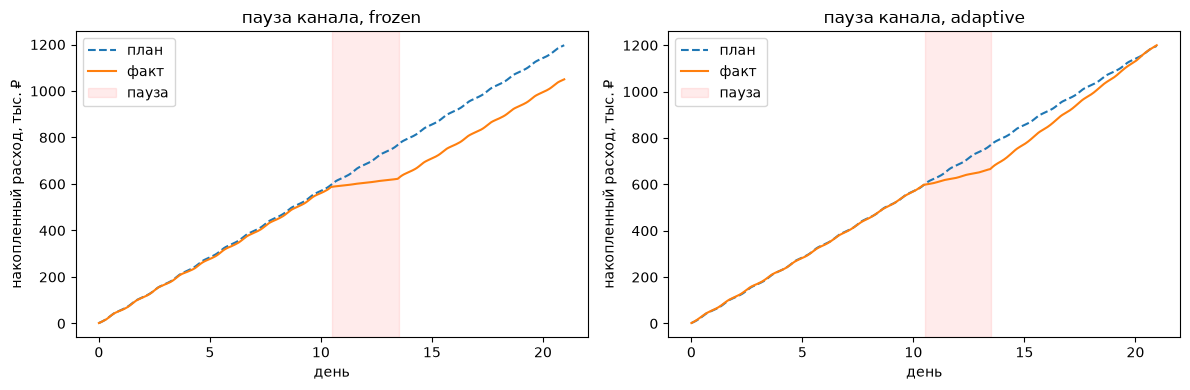

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (mode, title) in zip(axes, [('frozen', 'пауза канала, frozen'), ('adaptive', 'пауза канала, adaptive')]):
    t = traj(f'w2-c1-h3-pause-{mode}')
    ax.plot(t.hour / 24, t.plan_spend / 1e3, '--', label='план'); ax.plot(t.hour / 24, t.fact_spend / 1e3, label='факт')
    ax.axvspan(10.5, 13.5, color='red', alpha=0.08, label='пауза')
    ax.set_title(title); ax.set_xlabel('день'); ax.set_ylabel('накопленный расход, тыс. ₽'); ax.legend()
fig.tight_layout(); fig.savefig(FIG / 'pause_spend.png', dpi=120); plt.show()

При паузе frozen теряет бюджет канала и заканчивает с −8 % расхода; adaptive перекладывает деньги и приходит в план по расходу. По KPI разница между режимами при истории небольшая и разнонаправленная — см. таблицу ниже.

In [7]:
by = warm.set_index(['scenario', 'world_seed', 'mode'])['final_ape_kpi'].unstack('mode')
by['adaptive − frozen, п.п.'] = (by['adaptive'] - by['frozen']) * 100
by.style.format({'frozen': '{:.1%}', 'adaptive': '{:.1%}', 'adaptive − frozen, п.п.': '{:+.1f}'})

## Выводы

1. Главный источник ошибки — не шоки и не исполнение, а незнание рынка: план по серединам публичных диапазонов промахивается по KPI до 2 раз. История трёх кампаний на том же рынке убирает это: p90 модуля отклонения падает с 91 % до 21 %.
2. Расход держится у плана во всех режимах; единственный провал у frozen — пауза канала, adaptive его закрывает.
3. Adaptive пока максимизирует KPI, а не держит план: при опережении он усиливает перевыполнение, при отставании догоняет. Поэтому по KPI он не лучше frozen систематически. Следующий шаг — цель «удерживать утверждённую траекторию».
4. Остаточное смещение warm-плана +13 % — prior всё ещё немного занижает; параметры насыщения пока берутся из каталога.